# Theta Wake Calculations using PyABS

## TO DO:
    - Add Analytical Comparison

In [45]:
%load_ext autoreload
%autoreload 2

import numpy as np
    
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [46]:
from pyabs.core.basis import ABSBasisConfig, build_abs_basis
from pyabs.core.matrix import build_abs_matrix
from pyabs.core.wake import ThetaWake, WakeScale
from pyabs.solvers.eigensolvers import solve_eigenvalues

In [72]:
n_max=9
basis = build_abs_basis(np, ABSBasisConfig(n_max=n_max, q=0))

In [73]:
theta_wake = ThetaWake(W0=0.7)

In [74]:
matrix = build_abs_matrix(basis, wake_model=theta_wake, scale=WakeScale(w = 1))

In [75]:
eigenvalue_i = solve_eigenvalues(matrix)
eigenvalues = np.array(eigenvalue_i)

In [76]:
print(eigenvalues.shape)
print(eigenvalues)

(19,)
[-8.99997651+0.j -8.0000138 +0.j -6.99999997+0.j  8.99997476+0.j
  8.00001361+0.j  6.99999523+0.j -5.99997571+0.j -4.99993572+0.j
  5.99997502+0.j  4.99991717+0.j -3.99981743+0.j -2.99956159+0.j
  3.9998138 +0.j  2.999407  +0.j -1.99822497+0.j -0.99301902+0.j
  1.99816537+0.j  0.96861139+0.j  0.37465137+0.j]


In [77]:
sc = np.linspace(0, 2, num=600)
modes = np.arange(-n_max, (n_max)+1, dtype=int)
eigenscan = []
for i, q in enumerate(sc):
    basis = build_abs_basis(np, ABSBasisConfig(n_max=n_max, q=q))
    matrix = build_abs_matrix(basis, wake_model=theta_wake, scale=WakeScale(w = 1))
    eigenscan.append(np.array(solve_eigenvalues(matrix)))

In [78]:
#eigenscan=np.array(-np.imag(eigenscan)).T
im_eigenscan = np.array(-np.imag(eigenscan))
re_eigenscan = np.array(np.real(eigenscan))

In [79]:
def sort_by_continuity(eigenscan):
    sorted_scan = eigenscan.copy()
    n_steps, n_modes = eigenscan.shape

    for i in range(1, n_steps):
        prev = sorted_scan[i - 1]
        curr = sorted_scan[i].copy()

        used = set()
        new_order = np.zeros(n_modes, dtype=int)
        for j in range(n_modes):
            # find the closest unused eigenvalue in curr to prev[j]
            dists = np.abs(curr - prev[j])
            dists[list(used)] = np.inf
            best = np.argmin(dists)
            new_order[j] = best
            used.add(best)

        sorted_scan[i] = curr[new_order]

    return sorted_scan

im_eigenscan_tracked = sort_by_continuity(im_eigenscan)
re_eigenscan_tracked = sort_by_continuity(re_eigenscan)

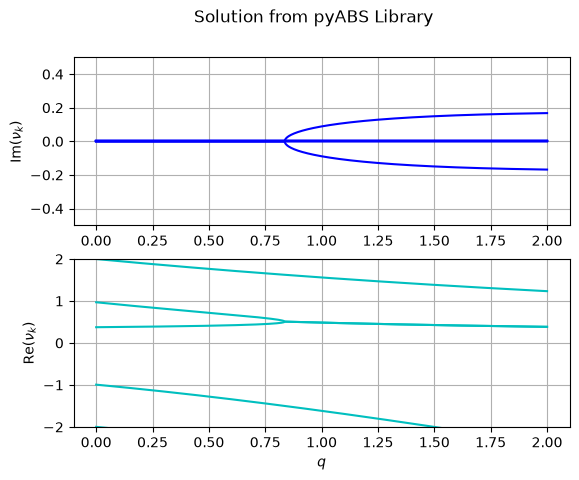

In [84]:
fig, ax = plt.subplots(2)
ax[0].set_ylim(-0.5,0.5)
ax[1].set_ylim(-2,2)
#ax[1].set_xlim(0,2)
#for i in range(len(modes)):
#    plt.scatter(sc, eigenscan[i])
plt.suptitle("Solution from pyABS Library")
ax[0].grid()
ax[1].grid()
ax[0].plot(sc, im_eigenscan_tracked, color='b')
ax[1].plot(sc, re_eigenscan_tracked, color='c')
ax[0].set_ylabel(r"Im($\nu_{k}$)")
ax[1].set_ylabel(r"Re($\nu_{k}$)")
ax[1].set_xlabel(r"$q$")
plt.savefig("../../plots/pyabs_theta.png", dpi=300)
plt.show()

compare with analytical solutions from burov
double check where the complex number went in burov

In [16]:
#analytic solutions
#analytic eigenvalues are given as
def real_eigen(n_max, q):
    modes = np.arange(-n_max, (n_max)+1, dtype=int)
    soln=[]
    for i in modes:
        if(i >= 0):
            soln.append(-q/2 + np.sqrt((q**2)/4 + i**2))
        if(i < 0):
            soln.append(-q/2 - np.sqrt((q**2)/4 + i**2))
    return soln

real_scan = []
#print(eigenscan_tracked)
analytical_solutions = []
for i, q in enumerate(sc):
    real_scan.append(real_eigen(n_max, q))
    


#print(eigenscan_tracked)
np.array(real_scan).shape

(600, 9)

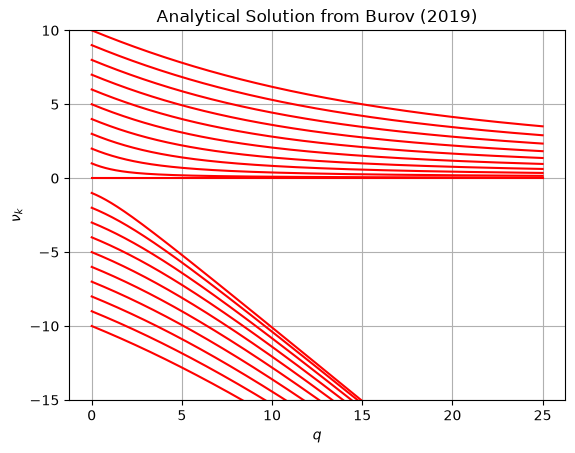

In [36]:
fig, ax = plt.subplots()
ax.set_ylim(-15,10)
plt.title("Analytical Solution from Burov (2019)")
plt.grid()
plt.plot(sc, real_scan, color='r')
ax.set_ylabel(r"$\nu_{k}$")
ax.set_xlabel(r"$q$")
plt.savefig("../../plots/analytical_nowake.png", dpi=300)
plt.show()

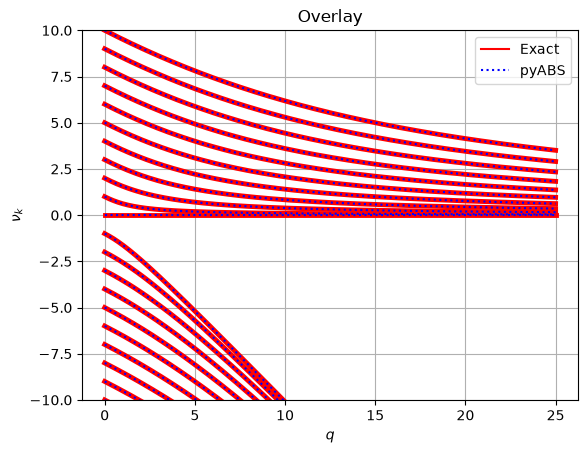

In [25]:
fig, ax = plt.subplots()
ax.set_ylim(-10,10)
plt.title("Overlay")
plt.grid()
plt.plot(sc, real_scan, color='r', lw=3.5)
plt.plot(sc, eigenscan_tracked, ':b')
plt.plot([],[], 'r', label='Exact')
plt.plot([],[], ':b', label="pyABS")
ax.legend()
ax.set_ylabel(r"$\nu_{k}$")
ax.set_xlabel(r"$q$")
plt.savefig("../../plots/overlay_nowake.png", dpi=300)
plt.show()